In [2]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))
print(gpus)

Num GPUs Available:  1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
import keras
from keras import layers

In [4]:
(x_train, y_train), (x_test, y_test) = df = tf.keras.datasets.cifar10.load_data()
labels = {0:    "airplane",
1:	"automobile",
2:	"bird",
3:	"cat",
4:	"deer",
5:	"dog",
6:	"frog",
7:	"horse",
8:	"ship",
9:	"truck"}

# EDA:

In [5]:
print('Shape of x_train is {}'.format(x_train.shape))
print('Shape of x_test is {}'.format(x_test.shape)) 
print('Shape of y_train is {}'.format(y_train.shape))
print('Shape of y_test is {}'.format(y_test.shape))

Shape of x_train is (50000, 32, 32, 3)
Shape of x_test is (10000, 32, 32, 3)
Shape of y_train is (50000, 1)
Shape of y_test is (10000, 1)


### Examining Image Dimensions:

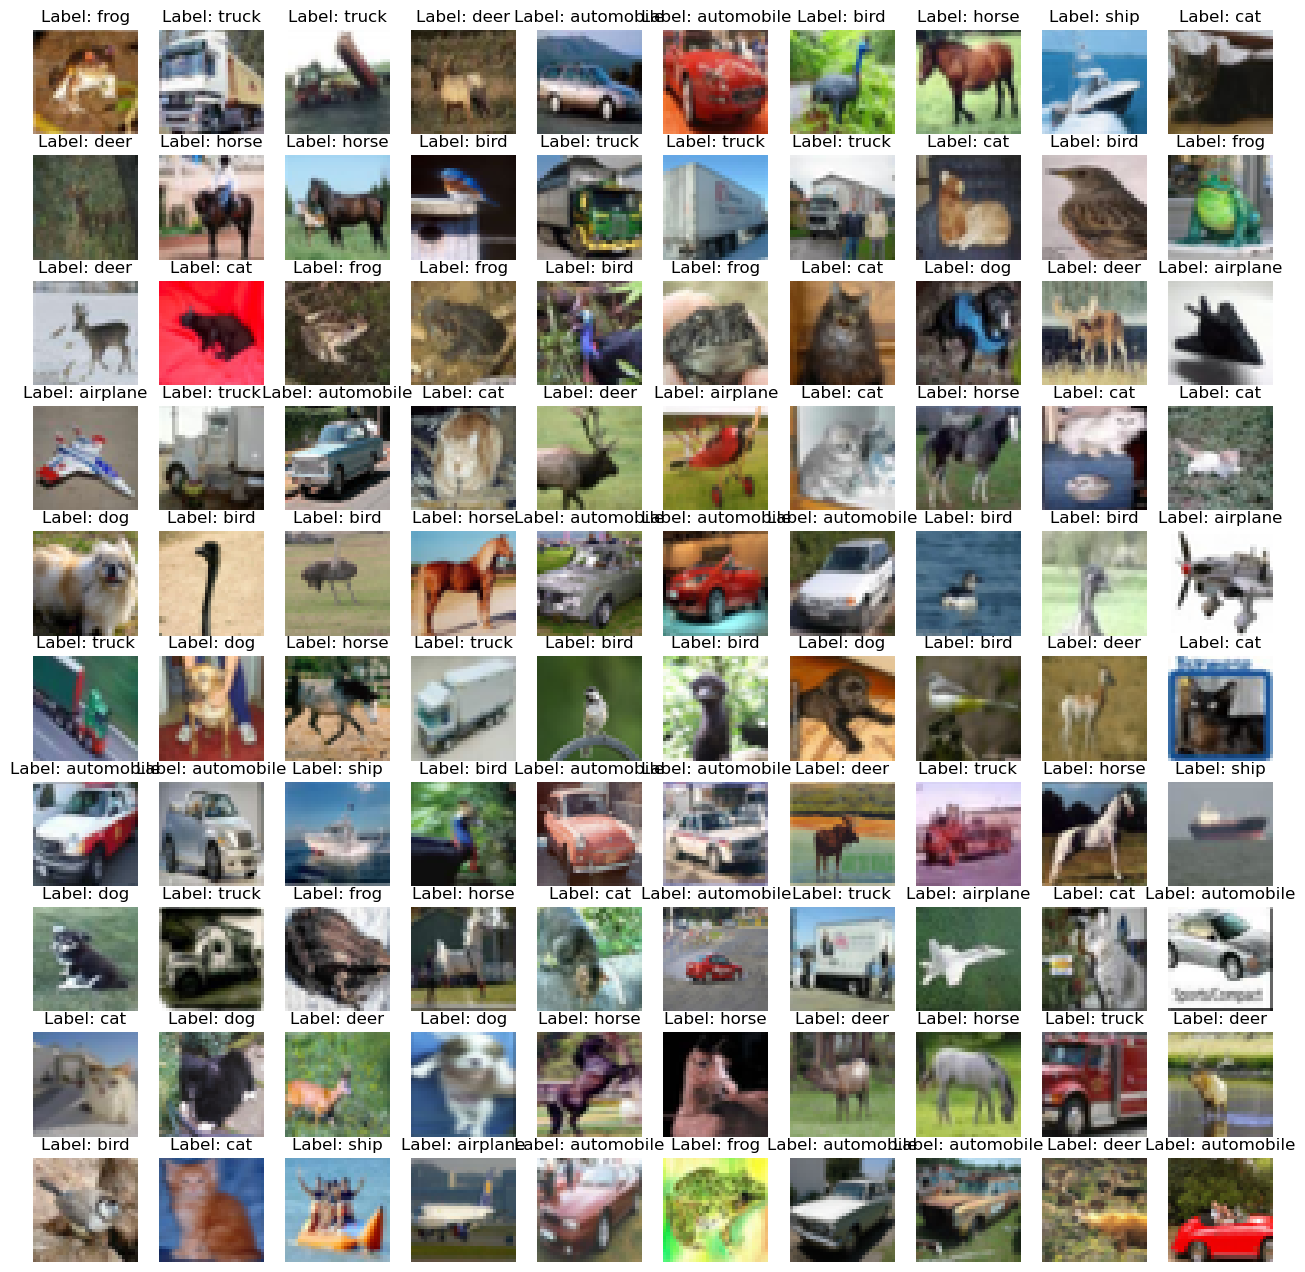

In [6]:
# Reshape to image dimensions (e.g., 32x32 for CIFAR-10)
pixels = x_train.reshape(x_train.shape[0], 32, 32, 3)  # Reshape to (num_samples, height, width, channels)
nolabels = y_train.flatten()  # Flatten labels to 1D array
nir = 10 # Number of images to display in each row and column
ax = plt.figure(figsize=(16, 16))
for index in range((nir*nir)):
    single_image = pixels[index]
    ax = plt.subplot(nir, nir, index+1)
    plt.imshow(single_image, cmap='gray')   
    plt.title(f"Label: {labels.get(nolabels[index])}")
    plt.axis('off')

Checking Class balance:

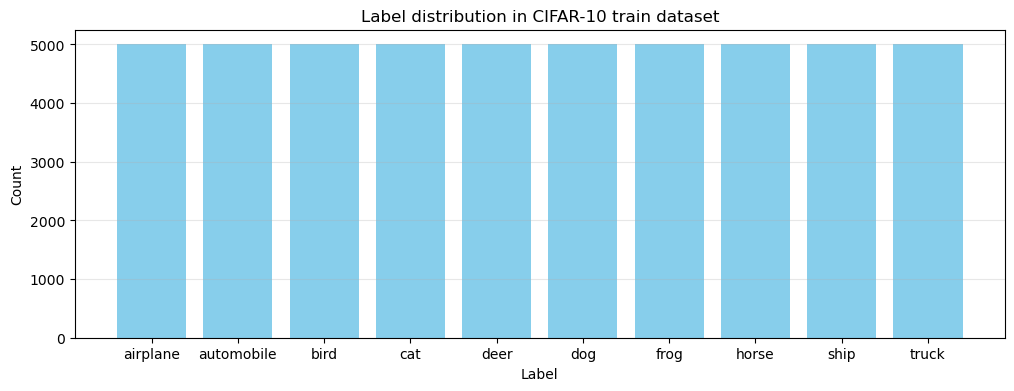

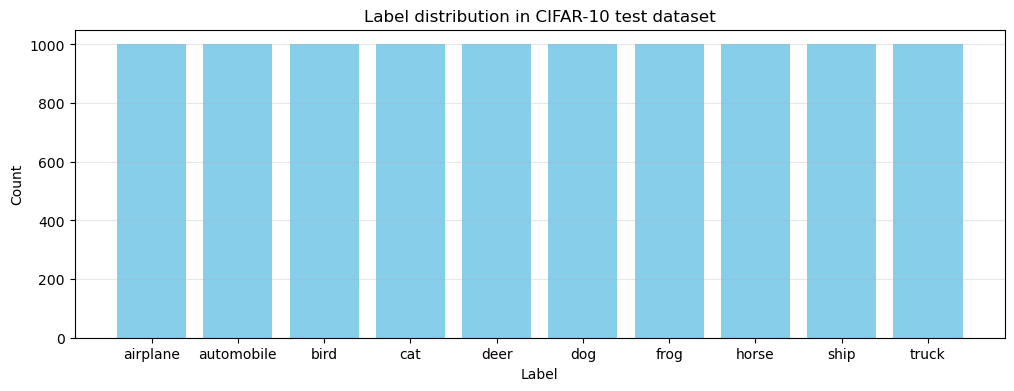

In [7]:
plt.figure(figsize=(12, 4))
plt.bar(labels.values(), np.bincount(y_train.flatten()), color='skyblue')
plt.title('Label distribution in CIFAR-10 train dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(12, 4))
plt.bar(labels.values(), np.bincount(y_test.flatten()), color='skyblue')
plt.title('Label distribution in CIFAR-10 test dataset')
plt.xlabel('Label')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Calculating stats of each of the channels for imgs:


In [8]:
print(f"Channel Means (R,G,B)for trian: {x_train.mean(axis=(0, 1, 2))}, Channel Std for train (R,G,B): {x_train.std(axis=(0, 1, 2))}")
print(f"Channel Means (R,G,B)for test: {x_test.mean(axis=(0, 1, 2))}, Channel Std for test (R,G,B): {x_test.std(axis=(0, 1, 2))}")

Channel Means (R,G,B)for trian: [125.30691805 122.95039414 113.86538318], Channel Std for train (R,G,B): [62.99321928 62.08870764 66.70489964]
Channel Means (R,G,B)for test: [126.02464141 123.7085042  114.85431865], Channel Std for test (R,G,B): [62.89639135 61.93752718 66.7060564 ]


It appears as if the blue channel has a lower intensity than the others throughout the dataset. This may cause some bias during training.

Text(0.5, 0, 'Pixel Intensity')

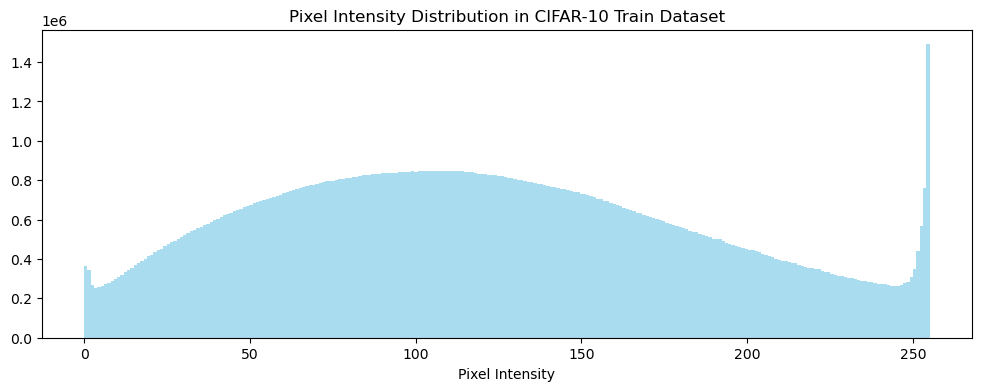

In [9]:
plt.figure(figsize=(12, 4))
plt.hist(x_train.flatten(), bins=256, color='skyblue', alpha=0.7)
plt.title('Pixel Intensity Distribution in CIFAR-10 Train Dataset')
plt.xlabel('Pixel Intensity')

It seems as if there is a sharp spike of pixels that lean towards pure white. This can be explained by looking at the above graphed images;
- Image Clipping (Sensor Saturation): Many of the 32x32 images in the dataset were captured under bright lighting, sunlight, or studio conditions. When a region of an object is brightly illuminated, the optical sensor in the camera records the light as maxed out. The sensor's data "clips" (or saturates) at the highest possible 8-bit integer value (255), leaving a cluster of maximum-intensity pixels.
- Specular Reflections: Shiny surfaces (like the hoods of cars, polished ship hulls, or animal eyes) create specular highlights. These direct reflections of a light source bounce brightly into the camera, appearing as pure white in an image and grouping pixels at the upper limits.
- Background Bias: Several classes in CIFAR-10 (like airplanes, cars, and certain animals) feature images photographed against artificial studio backdrops. These unicolor, uniform backgrounds are frequently set to pure white (R: 255, G: 255, B: 255) to cleanly isolate the foreground object, producing a massive accumulation of pixels at the 255 boundary.

## Data Preprocesing:


In [10]:
from tensorflow.keras.utils import to_categorical

# 1. Normalize pixel values to be between 0.0 and 1.0
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 2. One-hot encode targets (convert integer labels to binary class matrices)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 3. Get normalised values for mean and std of each channel
mean = x_train.mean(axis=(0, 1, 2))
std = x_train.std(axis=(0, 1, 2))

# Modeling (VAE):

In [11]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [12]:
latent_dim = 4 # This is the place to specify how many latent neurons you want in your VAE.

encoder_inputs = keras.Input(x_train.shape[1:]) # Shape of the input images (32x32 pixels with 3 color channels)
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
x = layers.Dense(16, activation="relu")(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 16, 16, 32)   896         ['input_1[0][0]']                
                                                                                                  
 conv2d_1 (Conv2D)              (None, 8, 8, 64)     18496       ['conv2d[0][0]']                 
                                                                                                  
 flatten (Flatten)              (None, 4096)         0           ['conv2d_1[0][0]']               
                                                                                            

In [13]:
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(8 * 8 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((8, 8, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(3, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 4)]               0         
                                                                 
 dense_3 (Dense)             (None, 4096)              20480     
                                                                 
 reshape (Reshape)           (None, 8, 8, 64)          0         
                                                                 
 conv2d_transpose (Conv2DTra  (None, 16, 16, 64)       36928     
 nspose)                                                         
                                                                 
 conv2d_transpose_1 (Conv2DT  (None, 32, 32, 32)       18464     
 ranspose)                                                       
                                                                 
 conv2d_transpose_2 (Conv2DT  (None, 32, 32, 3)        867 

In [14]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [15]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
history = vae.fit(x_train, epochs=50, batch_size=128)

Epoch 1/50
391/391 [==============================] - 18s 13ms/step - loss: 691.8746 - reconstruction_loss: 672.9835 - kl_loss: 3.8769
Epoch 2/50
391/391 [==============================] - 5s 13ms/step - loss: 657.7370 - reconstruction_loss: 652.3646 - kl_loss: 4.8645
Epoch 3/50
391/391 [==============================] - 5s 13ms/step - loss: 654.2969 - reconstruction_loss: 646.3432 - kl_loss: 5.1511
Epoch 4/50
391/391 [==============================] - 5s 13ms/step - loss: 647.7637 - reconstruction_loss: 642.5565 - kl_loss: 5.5397
Epoch 5/50
391/391 [==============================] - 5s 13ms/step - loss: 647.5325 - reconstruction_loss: 642.1960 - kl_loss: 5.5263
Epoch 6/50
391/391 [==============================] - 5s 13ms/step - loss: 647.8373 - reconstruction_loss: 642.0733 - kl_loss: 5.5161
Epoch 7/50
391/391 [==============================] - 5s 13ms/step - loss: 647.7031 - reconstruction_loss: 641.8839 - kl_loss: 5.5298
Epoch 8/50
391/391 [==============================] - 5s 13ms

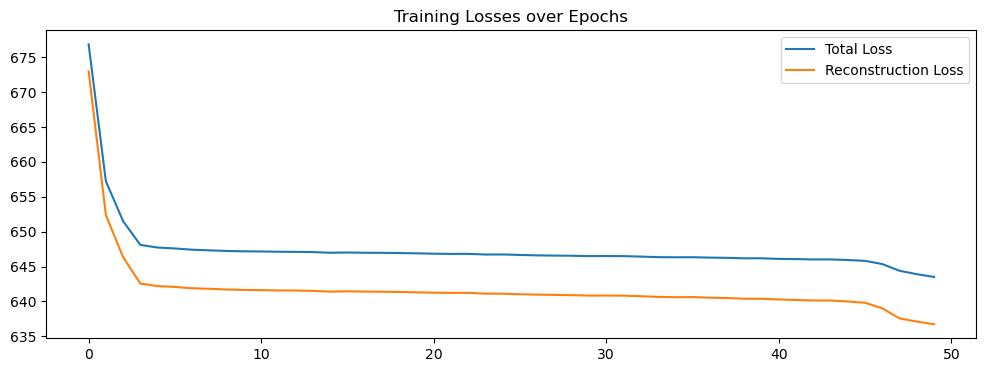

In [24]:
history_df = pd.DataFrame(history.history)
plt.figure(figsize=(12, 4))
plt.plot(history_df['loss'], label='Total Loss')
plt.plot(history_df['reconstruction_loss'], label='Reconstruction Loss')
plt.title('Training Losses over Epochs')
plt.legend()
plt.show()

In [17]:
vae.save_weights('baseline_vae_weights.h5')  # Save the weights of the trained VAE model

1/1 [==============================] - 0s 149ms/step


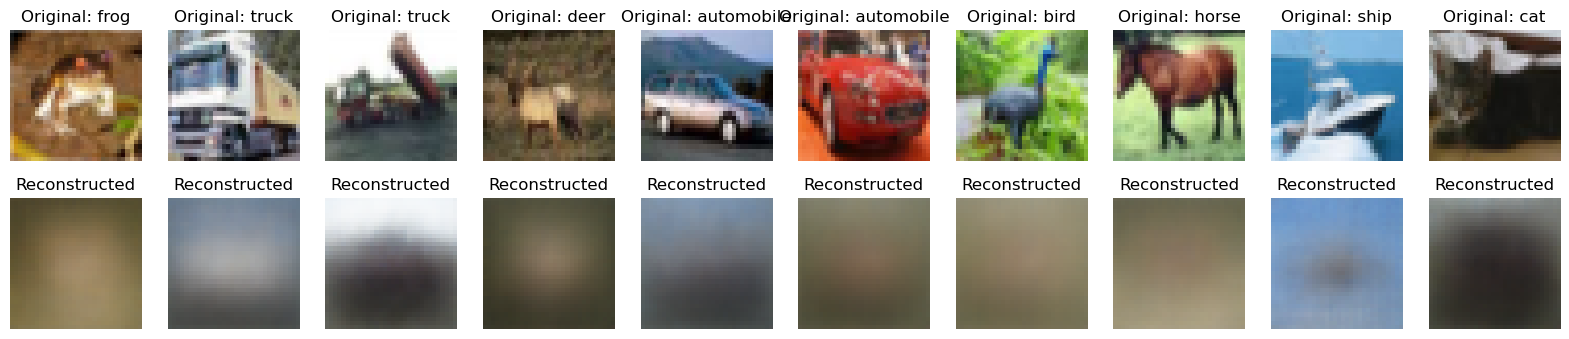

In [18]:
n = 10 
z_mean, z_log_var, z = encoder.predict(x_train[:n])
reconstruction = decoder.predict(z)
fig, ax = plt.subplots(2, n, figsize=(20, 4))
for i in range(n):
    # Display original images
    ax[0, i].imshow(x_train[i])
    ax[0, i].set_title(f"Original: {labels.get(np.argmax(y_train[i]))}")
    ax[0, i].axis('off')

    # Display reconstructed images
    ax[1, i].imshow(reconstruction[i])
    ax[1, i].set_title(f"Reconstructed")
    ax[1, i].axis('off')

157/157 [==============================] - 0s 3ms/step


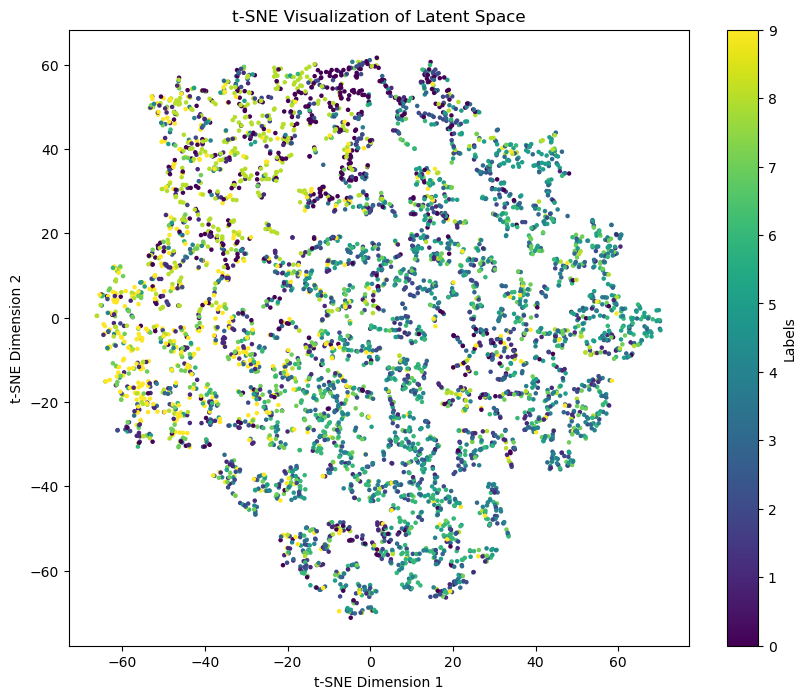

In [32]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def visualize_latent_space_tsne(vae, data, labels=None, n_samples=1000):
    """
    Visualize the 3D latent space using t-SNE.
    
    Parameters:
    - vae: The trained VAE model.
    - data: Input data to encode into the latent space.
    - labels: Optional labels for coloring the scatter plot.
    - n_samples: Number of samples to use for visualization.
    """
    # Encode the data into the latent space
    z_mean, _, _ = vae.encoder.predict(data[:n_samples])  # Shape: (n_samples, 3)

    # Apply t-SNE to reduce 3D latent space to 2D
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    z_tsne = tsne.fit_transform(z_mean)  # Shape: (n_samples, 2)

    # Plot the t-SNE projections
    plt.figure(figsize=(10, 8))
    if labels is not None:
        scatter = plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c=labels[:n_samples], cmap='viridis', s=5)
        plt.colorbar(scatter, label="Labels")
    else:
        plt.scatter(z_tsne[:, 0], z_tsne[:, 1], s=5)
    plt.title("t-SNE Visualization of Latent Space")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

# Example usage
# Assuming `x_test` is your test dataset and `y_test` are the corresponding labels
visualize_latent_space_tsne(vae, x_train, labels=np.argmax(y_train, axis=1), n_samples=5000)

The t-SNE visualization of the VAE latent space indicates that the learned latent representations are distributed across the embedding without forming clearly distinguishable clusters for the different class labels. Although the latent vectors occupy the entire two-dimensional space and exhibit some localized groupings, there is considerable overlap among samples from different classes, as indicated by the mixed colors throughout the plot. This suggests that while the VAE has learned meaningful compressed representations of the input data, the latent space does not strongly separate samples according to their labels. Such behavior is expected for a standard unsupervised VAE, whose objective is to reconstruct the input while regularizing the latent distribution rather than maximizing class discrimination. The absence of well-defined class boundaries implies that the latent features capture general characteristics of the data but are not sufficiently discriminative for classification tasks.

Based on these results, the VAE model can be improved by encouraging the latent space to learn more structured and separable representations. This can be achieved by increasing the latent dimensionality if the current bottleneck is too restrictive, or by tuning the KL divergence weight (e.g., using a β-VAE or KL annealing) to better balance reconstruction quality and latent regularization. If class separation is an important objective, incorporating supervised information through a Conditional VAE (CVAE) or a semi-supervised VAE can guide the latent space to organize samples according to their labels. Additionally, increasing the encoder and decoder capacity, optimizing hyperparameters such as learning rate and batch size, and training for more epochs may allow the model to learn richer feature representations. Finally, evaluating the latent space using quantitative metrics such as clustering scores or downstream classification accuracy can provide a more objective assessment of how informative and discriminative the learned embeddings are.

32/32 [==============================] - 0s 2ms/step


C:\Users\p2518127\AppData\Local\Temp\ipykernel_20296\2142071430.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Latent Space', y='Value', data=df_melted, palette="Set3", inner="box")


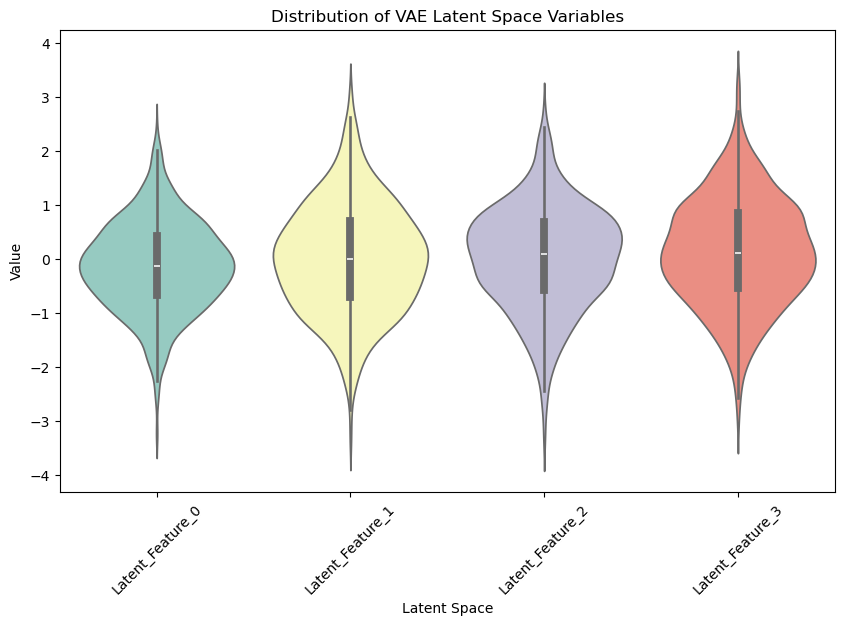

In [25]:
z_mean, _, _ = vae.encoder.predict(x_test[:1000])  # Use the first 10,000 samples for visualization

# 2. Reshape into a pandas DataFrame for Seaborn
# Assuming latent_dim is N. This creates columns like 'Latent_Feature_0'
import pandas as pd
import seaborn as sns
df = pd.DataFrame(z_mean, columns=[f"Latent_Feature_{i}" for i in range(z_mean.shape[1])])

# 3. Melt the dataframe to long-format for Seaborn
df_melted = df.melt(var_name='Latent Space', value_name='Value')

# 4. Plot the Violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Latent Space', y='Value', data=df_melted, palette="Set3", inner="box")
plt.title("Distribution of VAE Latent Space Variables")
plt.xticks(rotation=45)
plt.show()

The violin plot shows that the latent space variables are generally centered around zero, with all four latent features exhibiting approximately symmetric distributions and similar overall shapes. This indicates that the VAE has learned latent representations that are reasonably aligned with the standard normal prior, which is one of the primary objectives of variational autoencoders. The median values of each latent feature are close to zero, while the interquartile ranges are relatively similar, suggesting that no single latent dimension dominates the representation. However, slight differences in the spread and density of the distributions can be observed, with some latent variables displaying broader tails and higher variability than others. This implies that certain latent dimensions encode more information than others, although none appear to have completely collapsed to a constant value. The overlap in the distributions also suggests that the latent variables are not yet fully disentangled, meaning that multiple latent dimensions may still capture correlated aspects of the input data.

Based on these results, the VAE appears to have learned a stable and meaningful latent representation, but there is still room for improvement. If the objective is to obtain a more structured and disentangled latent space, the KL divergence weight (β) can be tuned, such as by using a β-VAE or KL annealing strategy to better balance reconstruction quality and latent regularization. Increasing the model capacity through additional hidden layers or latent dimensions may also allow the encoder to capture more complex patterns if the current latent space is too restrictive. Conversely, if some latent dimensions contribute very little, reducing the latent dimensionality can eliminate redundant features and improve representation efficiency. Monitoring both reconstruction loss and KL divergence during training, along with visualizing the latent space using techniques such as PCA or t-SNE, can further help determine whether the learned latent variables are informative, well-separated, and suitable for downstream tasks.

### Model Improvement
Using he conclusions we drew from the analysis, we now create an improved VAE model. The improvements include the use of a β-VAE (to better balance reconstruction and latent regularization) and an increase in the latent dimensionality. Additionally, the model structure is enhanced with deeper encoder and decoder networks.

In [38]:
from tensorflow.keras import layers, Model
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.optimizers import Adam

# Reuse the Sampling layer from the previous code

# Define the encoder (reuse and extend the existing structure)
def build_encoder(input_shape, latent_dim):
    encoder_inputs = keras.Input(shape=input_shape)  # Shape of the input images
    x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
    x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])  # Reuse the Sampling layer
    return keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Define the decoder
def build_decoder(latent_dim, output_shape):
    latent_inputs = layers.Input(shape=(latent_dim,))
    x = layers.Dense(8 * 8 * 64, activation="relu")(latent_inputs)
    x = layers.Reshape((8, 8, 64))(x)
    x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
    x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
    outputs = layers.Conv2DTranspose(output_shape[-1], 3, activation="sigmoid", padding="same")(x)
    return keras.Model(latent_inputs, outputs, name="decoder")

# Define the VAE model (reuse the Sampling layer and encoder/decoder)
class VAE(Model):
    def __init__(self, encoder, decoder, beta=1.0, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.beta = beta
        self.total_loss_tracker = tf.keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)
        return reconstructed

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstructed = self.decoder(z)
            # Ensure reconstruction loss sums over the correct dimensions
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(tf.keras.losses.mean_squared_error(data, reconstructed), axis=(1, 2))
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = reconstruction_loss + self.beta * kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

# Hyperparameters
latent_dim = 10  # Increased latent dimensionality
beta = 4.0  # β-VAE with higher KL divergence weight

# Build the model
encoder = build_encoder(x_train.shape[1:], latent_dim)
decoder = build_decoder(latent_dim, x_train.shape[1:])
vae = VAE(encoder, decoder, beta=beta)

In [43]:
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

stop_early = [EarlyStopping(monitor='loss', patience=5, verbose=1),
ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)]

# Compile and train the model
vae.compile(optimizer=Adam(learning_rate=0.001))
vae.fit(x_train, epochs=50, batch_size=128, callbacks=stop_early)

Epoch 1/50
391/391 [==============================] - 6s 12ms/step - loss: 47.6408 - reconstruction_loss: 39.1344 - kl_loss: 2.1773 - lr: 0.0010
Epoch 2/50
391/391 [==============================] - 5s 13ms/step - loss: 47.8649 - reconstruction_loss: 39.0976 - kl_loss: 2.1768 - lr: 0.0010
Epoch 3/50
391/391 [==============================] - 5s 12ms/step - loss: 47.7837 - reconstruction_loss: 39.0635 - kl_loss: 2.1760 - lr: 0.0010
Epoch 4/50
391/391 [==============================] - 5s 13ms/step - loss: 47.8469 - reconstruction_loss: 39.1016 - kl_loss: 2.1810 - lr: 0.0010
Epoch 5/50
391/391 [==============================] - 5s 13ms/step - loss: 47.8576 - reconstruction_loss: 39.0814 - kl_loss: 2.1814 - lr: 0.0010
Epoch 6/50
389/391 [============================>.] - ETA: 0s - loss: 47.8418 - reconstruction_loss: 39.0604 - kl_loss: 2.1835
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
391/391 [==============================] - 5s 13ms/step - loss: 47.8414 

157/157 [==============================] - 0s 3ms/step


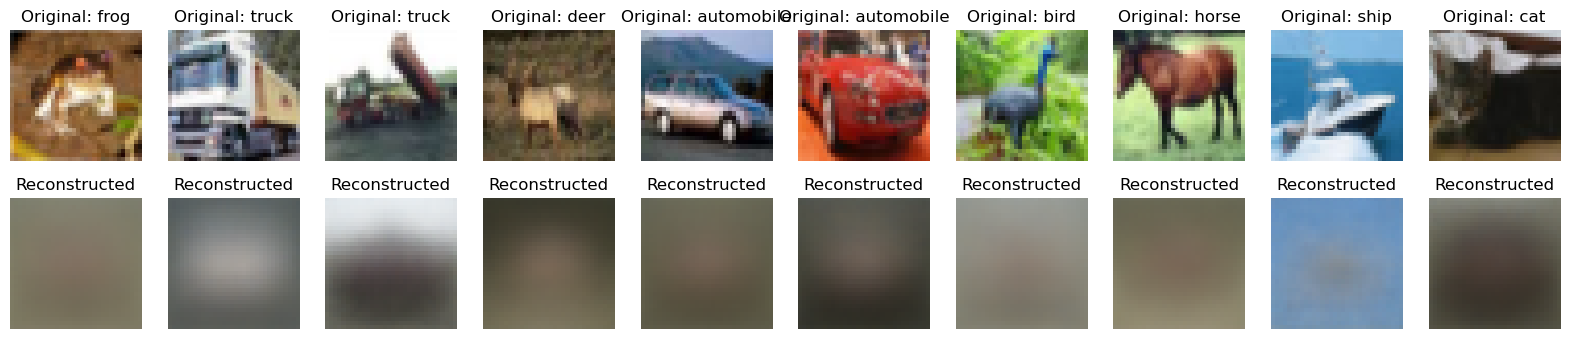

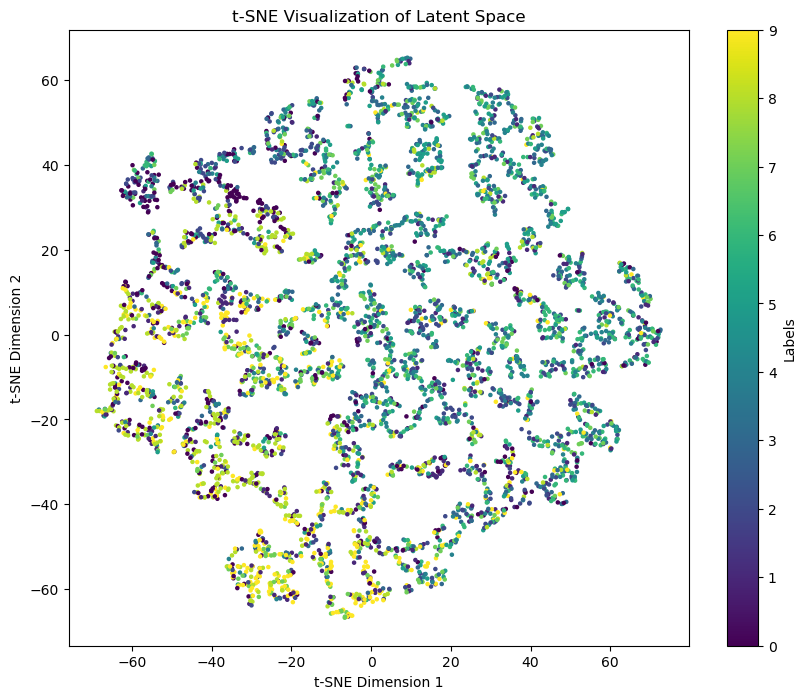

32/32 [==============================] - 0s 3ms/step


C:\Users\p2518127\AppData\Local\Temp\ipykernel_20296\1976592492.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Latent Space', y='Value', data=df_melted, palette="Set3", inner="box")


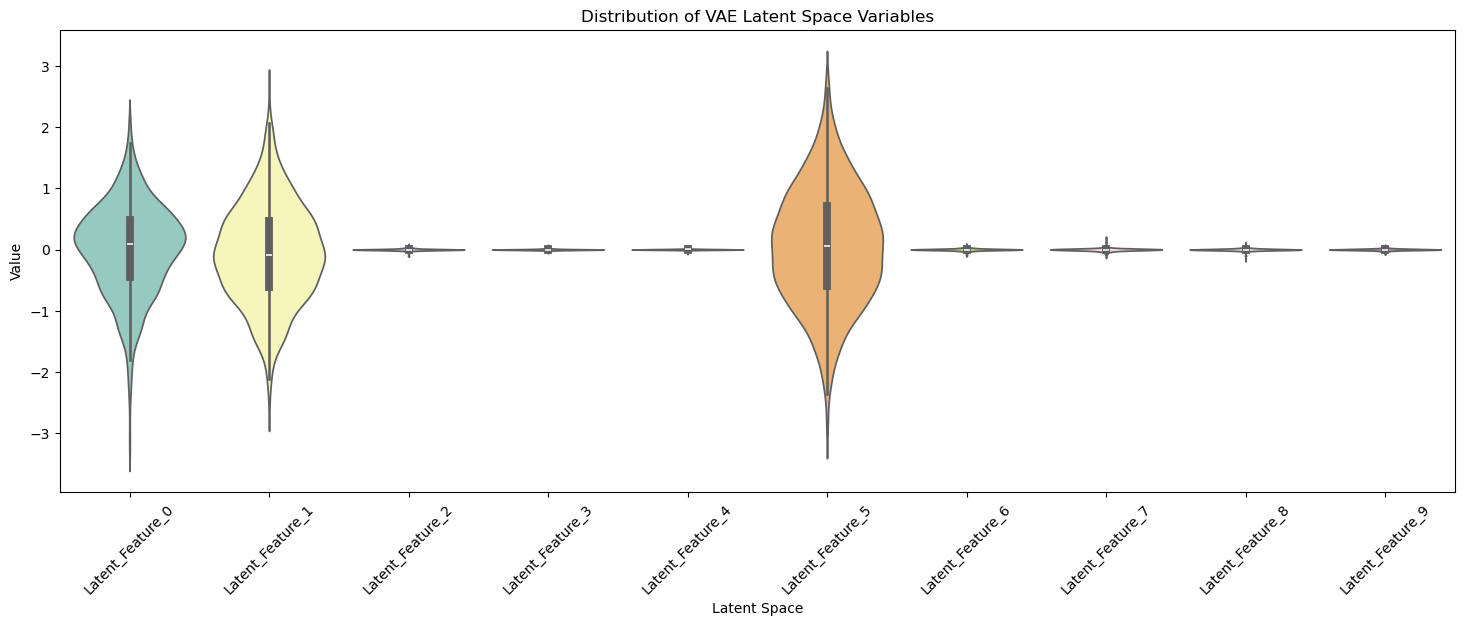

In [ ]:
n = 10 
z_mean, z_log_var, z = encoder.predict(x_train[:n])
reconstruction = decoder.predict(z)
fig, ax = plt.subplots(2, n, figsize=(20, 4))
for i in range(n):
    # Display original images
    ax[0, i].imshow(x_train[i])
    ax[0, i].set_title(f"Original: {labels.get(np.argmax(y_train[i]))}")
    ax[0, i].axis('off')

    # Display reconstructed images
    ax[1, i].imshow(reconstruction[i])
    ax[1, i].set_title(f"Reconstructed")
    ax[1, i].axis('off')

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

def visualize_latent_space_tsne(vae, data, labels=None, n_samples=1000):
    """
    Visualize the 3D latent space using t-SNE.
    
    Parameters:
    - vae: The trained VAE model.
    - data: Input data to encode into the latent space.
    - labels: Optional labels for coloring the scatter plot.
    - n_samples: Number of samples to use for visualization.
    """
    # Encode the data into the latent space
    z_mean, _, _ = vae.encoder.predict(data[:n_samples])  # Shape: (n_samples, 3)

    # Apply t-SNE to reduce 3D latent space to 2D
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    z_tsne = tsne.fit_transform(z_mean)  # Shape: (n_samples, 2)

    # Plot the t-SNE projections
    plt.figure(figsize=(10, 8))
    if labels is not None:
        scatter = plt.scatter(z_tsne[:, 0], z_tsne[:, 1], c=labels[:n_samples], cmap='viridis', s=5)
        plt.colorbar(scatter, label="Labels")
    else:
        plt.scatter(z_tsne[:, 0], z_tsne[:, 1], s=5)
    plt.title("t-SNE Visualization of Latent Space")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.show()

# Example usage
# Assuming `x_test` is your test dataset and `y_test` are the corresponding labels
visualize_latent_space_tsne(vae, x_train, labels=np.argmax(y_train, axis=1), n_samples=5000)
z_mean, _, _ = vae.encoder.predict(x_test[:1000])  # Use the first 10,000 samples for visualization

# 2. Reshape into a pandas DataFrame for Seaborn
# Assuming latent_dim is N. This creates columns like 'Latent_Feature_0'
import pandas as pd
import seaborn as sns
df = pd.DataFrame(z_mean, columns=[f"Latent_Feature_{i}" for i in range(z_mean.shape[1])])

# 3. Melt the dataframe to long-format for Seaborn
df_melted = df.melt(var_name='Latent Space', value_name='Value')

# 4. Plot the Violin plot
plt.figure(figsize=(18, 6))
sns.violinplot(x='Latent Space', y='Value', data=df_melted, palette="Set3", inner="box")
plt.title("Distribution of VAE Latent Space Variables")
plt.xticks(rotation=45)
plt.show()

The visual fidelity of the reconstructed images look about the same as the baseline model.

More distinct clustering can be seen in the TSNE, there is considerable overlap among samples from different classes, as indicated by the mixed colors throughout the plot. This suggests that while the VAE has learned meaningful compressed representations of the input data, the latent space does not strongly separate samples according to their labels. Such behavior is expected for a standard unsupervised VAE, whose objective is to reconstruct the input while regularizing the latent distribution rather than maximizing class discrimination. The absence of well-defined class boundaries implies that the latent features capture general characteristics of the data but are not sufficiently discriminative for classification tasks.

The violin plot reveals that only a small subset of the latent dimensions—specifically **Latent_Feature_0, Latent_Feature_1, and Latent_Feature_5**—exhibit meaningful variability, with distributions that are approximately centered around zero and spread across a relatively wide range of values. These latent variables appear to encode most of the information learned by the VAE, as evidenced by their broad distributions and larger interquartile ranges. In contrast, the remaining latent features (**Latent_Feature_2, Latent_Feature_3, Latent_Feature_4, and Latent_Feature_6 to Latent_Feature_9**) are highly concentrated around zero with almost no variance, indicating that they contribute very little to the learned representation. This phenomenon is commonly referred to as **latent dimension collapse** or **inactive latent units**, where the encoder effectively ignores several latent variables because they are not needed for minimizing the reconstruction and KL divergence losses.

The presence of multiple inactive latent dimensions suggests that the current latent space is over-parameterized, meaning the model does not require all ten latent variables to represent the underlying data. Instead, the VAE has learned to encode most of the information into only three active dimensions while leaving the remaining dimensions close to the prior distribution. Although the active latent variables are reasonably centered around zero, indicating that the KL regularization is functioning as intended, the imbalance in latent utilization implies that the learned representation is not fully exploiting the available latent capacity.

Based on these results, the VAE can be improved by encouraging more effective use of the latent dimensions. One approach is to reduce the latent dimensionality (e.g., from 10 to 3–5 dimensions), which would eliminate redundant latent variables and produce a more compact representation. Alternatively, if a higher-dimensional latent space is desired, techniques such as **KL annealing**, **β-VAE tuning**, or **free bits** can reduce posterior collapse and encourage the model to utilize more latent units. Increasing the complexity of the encoder and decoder or adjusting the balance between reconstruction loss and KL divergence may also help distribute information more evenly across the latent space.

### Addressing posterior collapse
KL annealing, free bits, and regularization of latent dimensions from analysis, and applications of methods from this paper: https://arxiv.org/html/2309.13160v3

In [46]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam

#############################################################
# Sampling Layer
#############################################################
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon
#############################################################
# Encoder
#############################################################
def build_encoder(input_shape, latent_dim):

    encoder_inputs = keras.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, strides=2,
                      padding="same",
                      activation="relu")(encoder_inputs)
    x = layers.Conv2D(64, 3, strides=2,
                      padding="same",
                      activation="relu")(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dense(128, activation="relu")(x)
    z_mean = layers.Dense(latent_dim, name="z_mean")(x)
    z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
    z = Sampling()([z_mean, z_log_var])
    return keras.Model(
        encoder_inputs,
        [z_mean, z_log_var, z],
        name="encoder"
    )
#############################################################
# Decoder
#############################################################
def build_decoder(latent_dim, output_shape):
    latent_inputs = keras.Input(shape=(latent_dim,))
    x = layers.Dense(8 * 8 * 64, activation="relu")(latent_inputs)
    x = layers.Reshape((8, 8, 64))(x)
    x = layers.Conv2DTranspose(
        64,
        3,
        strides=2,
        padding="same",
        activation="relu")(x)
    x = layers.Conv2DTranspose(
        32,
        3,
        strides=2,
        padding="same",
        activation="relu")(x)
    outputs = layers.Conv2DTranspose(
        output_shape[-1],
        3,
        padding="same",
        activation="sigmoid")(x)
    return keras.Model(
        latent_inputs,
        outputs,
        name="decoder"
    )
#############################################################
# Improved VAE
#############################################################
class ImprovedVAE(Model):
    def __init__(
        self,
        encoder,
        decoder,
        beta=4.0,
        free_bits=0.1,
        kl_anneal_rate=0.01,
        lambda_var=0.05,
        target_variance=1.0,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.encoder = encoder
        self.decoder = decoder

        self.beta = beta
        self.current_beta = 0.0
        self.kl_anneal_rate = kl_anneal_rate

        self.free_bits = free_bits

        self.lambda_var = lambda_var
        self.target_variance = target_variance

        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(
            name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")
        self.variance_loss_tracker = tf.keras.metrics.Mean(
            name="variance_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
            self.variance_loss_tracker,
        ]

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstructed = self.decoder(z)
        return reconstructed
    
    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            ###############################################
            # Forward pass
            ###############################################
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            ###############################################
            # Reconstruction loss
            ###############################################
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.mean_squared_error(
                        data,
                        reconstruction
                    ),
                    axis=(1, 2)
                )
            )
            ###############################################
            # KL Divergence
            ###############################################
            kl_per_dim = -0.5 * (
                1
                + z_log_var
                - tf.square(z_mean)
                - tf.exp(z_log_var)
            )
            ###############################################
            # Free Bits (per latent dimension)
            ###############################################
            kl_per_dim = tf.maximum(
                kl_per_dim,
                self.free_bits
            )
            kl_loss = tf.reduce_mean(
                tf.reduce_sum(kl_per_dim, axis=1)
            )
            ###############################################
            # Variance Regularization (Section 3.3)
            ###############################################
            variance = tf.exp(z_log_var)
            variance_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.square(
                        variance - self.target_variance
                    ),
                    axis=1
                )
            )
            ###############################################
            # Total Loss
            ###############################################
            total_loss = (
                reconstruction_loss
                + self.current_beta * kl_loss
                + self.lambda_var * variance_loss
            )
        gradients = tape.gradient(
            total_loss,
            self.trainable_weights
        )
        self.optimizer.apply_gradients(
            zip(gradients, self.trainable_weights)
        )
        ###############################################
        # Update metrics
        ###############################################
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(
            reconstruction_loss
        )
        self.kl_loss_tracker.update_state(kl_loss)
        self.variance_loss_tracker.update_state(
            variance_loss
        )
        ###############################################
        # KL Annealing
        ###############################################
        self.current_beta = min(
            self.beta,
            self.current_beta + self.kl_anneal_rate
        )
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss":
                self.reconstruction_loss_tracker.result(),
            "kl_loss":
                self.kl_loss_tracker.result(),
            "variance_loss":
                self.variance_loss_tracker.result(),
            "beta":
                self.current_beta,
        }
#############################################################
# Hyperparameters
#############################################################

latent_dim = 10

beta = 4.0

free_bits = 0.1

kl_anneal_rate = 0.01

lambda_var = 0.05

#############################################################
# Build model
#############################################################

encoder = build_encoder(
    x_train.shape[1:],
    latent_dim
)

decoder = build_decoder(
    latent_dim,
    x_train.shape[1:]
)

vae = ImprovedVAE(
    encoder,
    decoder,
    beta=beta,
    free_bits=free_bits,
    kl_anneal_rate=kl_anneal_rate,
    lambda_var=lambda_var
)

#############################################################
# Compile
#############################################################

vae.compile(
    optimizer=Adam(learning_rate=1e-3)
)

### Explanation of methods from paper https://arxiv.org/html/2309.13160v3:
The paper proposes adding a **variance regularization term** that explicitly prevents the encoder variances from collapsing. Section 3.3 introduces an additional loss.
#### What Section 3.3 does
Encoder predicts
## q(z∣x)=N(μ,σ2)
where
```
z_mean
z_log_var
```
are learned.
The paper observes that during training

* σ becomes extremely small
* several latent variables become deterministic
* inactive latent units appear
* posterior collapse occurs

They therefore add a penalty encouraging the latent variances to remain close to a desired variance rather than shrinking toward zero.
Currently the loss is
```
total_loss =
    reconstruction_loss
    + beta * kl_loss
```
Instead it becomes
```
total_loss =
    reconstruction_loss
    + beta * kl_loss
    + lambda_var * variance_regularizer
```
### Step 1: Compute the variance
Convert it to variance
```python
variance = tf.exp(z_log_var)
```
### Step 2: Add the variance regularizer
One simple implementation consistent with the paper is

```
target_variance = 1.0

variance_loss = tf.reduce_mean(
    tf.square(variance - target_variance)
)
```
This penalizes latent dimensions whose variance collapses toward zero.
### Step 3: Weight it
Add a coefficient
```
lambda_var = 0.05
```
Then
```
total_loss = (
    reconstruction_loss
    + self.current_beta * kl_loss
    + lambda_var * variance_loss
)
```
### train_step becomes
```
variance = tf.exp(z_log_var)

variance_loss = tf.reduce_mean(
    tf.square(variance - 1.0)
)

total_loss = (
    reconstruction_loss
    + self.current_beta * kl_loss
    + 0.05 * variance_loss
)
```
Track it like KL loss
```
self.variance_tracker.update_state(variance_loss)
```
### Even better: Per-dimension variance
Instead of averaging everything,
```
variance = tf.exp(z_log_var)

variance_loss = tf.reduce_mean(
    tf.reduce_sum(
        tf.square(variance - 1.0),
        axis=1
    )
)
```
This encourages **every latent dimension** to stay active rather than allowing only a few dimensions to carry all the information.

### Combined loss

## L = MSE​​​+β(t)(KL​​)​+λv(variance_loss​​​)
β(t) is free bits.


In [47]:
#############################################################
# Train
#############################################################

history = vae.fit(
    x_train,
    epochs=50,
    batch_size=128,
    callbacks=[
        EarlyStopping(monitor='loss', patience=5, verbose=1),
        ReduceLROnPlateau(monitor='loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ]
)

Epoch 1/50
391/391 [==============================] - 6s 13ms/step - loss: 39.4462 - reconstruction_loss: 38.7202 - kl_loss: 28.8970 - variance_loss: 8.7401 - beta: 0.0200 - lr: 0.0010
Epoch 2/50
391/391 [==============================] - 5s 13ms/step - loss: 23.7933 - reconstruction_loss: 22.9077 - kl_loss: 38.7061 - variance_loss: 9.9709 - beta: 0.0200 - lr: 0.0010
Epoch 3/50
391/391 [==============================] - 5s 13ms/step - loss: 22.6323 - reconstruction_loss: 21.7694 - kl_loss: 36.4103 - variance_loss: 9.9756 - beta: 0.0200 - lr: 0.0010
Epoch 4/50
391/391 [==============================] - 5s 13ms/step - loss: 22.3831 - reconstruction_loss: 21.5306 - kl_loss: 35.3607 - variance_loss: 9.9774 - beta: 0.0200 - lr: 0.0010
Epoch 5/50
391/391 [==============================] - 5s 13ms/step - loss: 22.2378 - reconstruction_loss: 21.3897 - kl_loss: 34.9101 - variance_loss: 9.9784 - beta: 0.0200 - lr: 0.0010
Epoch 6/50
391/391 [==============================] - 5s 13ms/step - loss: 

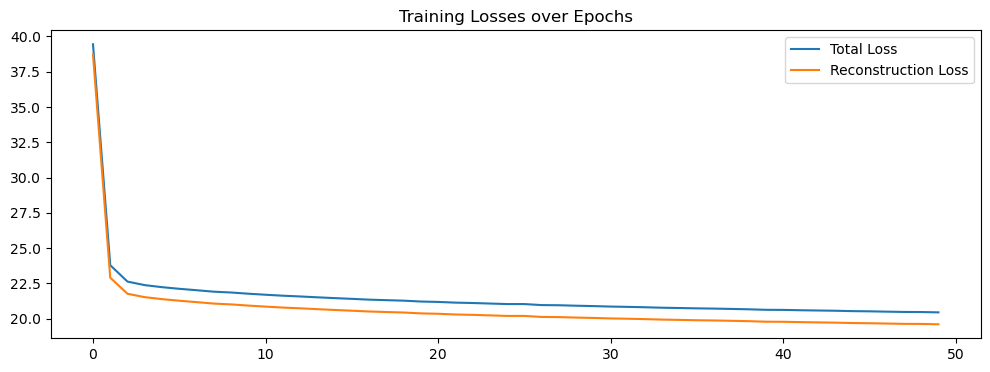

In [48]:
history_df = pd.DataFrame(history.history)
plt.figure(figsize=(12, 4))
plt.plot(history_df['loss'], label='Total Loss')
plt.plot(history_df['reconstruction_loss'], label='Reconstruction Loss')
plt.title('Training Losses over Epochs')
plt.legend()
plt.show()